(4c) Write code to integrate the LIF equation with this input and verify the formula from (b). Use R = 1 Ω, τm = 10 ms, τs = 2 ms, urest = 0 mV, uth = 1 mV. Report tpeak, Icrit0, and the numerically measured peak voltage at each of three amplitudes in a small table, to four digits. Plot u(t) for I0 below, at, and, above Icrit0 on one set of axes with the threshold drawn as a horizontal line. Then plot Icrit0 against τs overτs ∈ [0.5, 100] ms on log-log axes and comment on the two limits.

In [74]:
# Libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Integrate LIF_sim - code from Canvas file lif_sim.py

In [75]:
def lif_sim(I=1.1, T=10.0, dt=1e-3, taum=1.0, R=1.0, urest=0.0, uth=1.0,
            sigma=0.0, seed=None):
    """Integrate the LIF model by Euler-Maruyama.

    I : constant, or a callable I(t). Anything time dependent goes here,
        e.g. lambda t: 1 + 2*np.sin(t) for a modulated drive.
    sigma : white noise amplitude; the increment is sqrt(2*dt)*sigma*randn.
    Returns t, u, spikes, rate (Hz, 0 if fewer than two spikes).
    """
    rng = np.random.default_rng(seed)
    Ifun = I if callable(I) else (lambda t: I)

    nt = int(round(T / dt)) + 1
    t = np.linspace(0.0, T, nt)
    u = np.zeros(nt)
    u[0] = urest
    spikes = []

    for j in range(nt - 1):
        du = dt * (R * Ifun(t[j]) - (u[j] - urest)) / taum
        if sigma:
            du += np.sqrt(2 * dt) * sigma * rng.standard_normal()
        u[j + 1] = u[j] + du
        if u[j + 1] > uth:
            u[j + 1] = urest
            spikes.append(t[j + 1])

    spikes = np.array(spikes)
    rate = 1000 * (len(spikes) - 1) / (spikes[-1] - spikes[0]) if len(spikes) >= 2 else 0.0
    return t, u, spikes, rate

Verifying from 4b

In [76]:
# Set parameters for 4c
R = 1.0         # Ohm
tau_m = 10.0    # ms 
tau_s = 2.0     # ms 
u_rest = 0.0    # mV
u_th = 1.0      # mV

In [77]:
# Solve LIF using the set 4c parameters
def solve_lif(t, I0, R=R, tau_m=tau_m, u_rest=u_rest, u_th=u_th):
    t = np.array(t, dtype=float)
    eqn = (R*I0*tau_s) / (tau_s - tau_m)
    return u_rest + eqn * (np.exp(-t/tau_s) - np.exp(-t/tau_m))     # bring in u_rest as baseline as u_rest = u(0) = 0

In [78]:
# Find t_peak and Icrit0
r = tau_s/tau_m     # Equation from 4b
t_peak = (tau_m * tau_s) / (tau_s - tau_m) * np.log(tau_s/tau_m)  # Equation rom 4b
Icrit0 = ((u_th - u_rest)/R) * ((tau_s/tau_m)**(1/((tau_s/tau_m)-1)))   # From my derivation of Icrit0 in 4b 

print(f"t_peak = {t_peak:.4f} ms")
print(f"Icrit0 = {Icrit0:.4f}")



t_peak = 4.0236 ms
Icrit0 = 7.4767


In [79]:
# Peak voltages
cat = [("Below Icrit0 (75%)", 0.75 * Icrit0),
       ("At Icrit0 (100%)", 1.0 * Icrit0),
       ("Above Icrit0 (125%)", 1.25 * Icrit0)]

# Build and fill table
results = []
plot_data = []

for label, I0 in cat:
    I_t = lambda t, I0 = I0: I0 * np.exp(-t/tau_s)
    t, u, spikes, rate = lif_sim(I = I_t, T = 24 * t_peak, dt = 1e-3, taum = tau_m, R = R, urest = u_rest, uth = np.inf, sigma = 0.0, seed = None)

    u_peak_vals = u.max()
    t_peak_vals = t[np.argmax(u)]
    results.append([label,
                    I0,
                    u_peak_vals,
                    t_peak_vals])

    plot_data.append([
        label,
        I0, 
        t_peak_vals,
        u_peak_vals, 
        t,
        u
    ])

df = pd.DataFrame(results, 
                  columns=[
                      "Amplitude relative to Icrit0",
                      "I0 (mA)", 
                      "u_peak (mV)", 
                      "t_peak (ms)"])
df.style.format({
    "I0 (mA)": "{:.4f}",
    "u_peak (mV)": "{:.4f}",
    "t_peak (ms)": "{:.4f}"
})





,Amplitude relative to Icrit0,I0 (mA),u_peak (mV),t_peak (ms)
0,Below Icrit0 (75%),5.6076,0.7502,4.0240
1,At Icrit0 (100%),7.4767,1.0003,4.0240
2,Above Icrit0 (125%),9.3459,1.2504,4.0240


Plot: u(t) for I0 below, at, and above Icrit0 with threshold

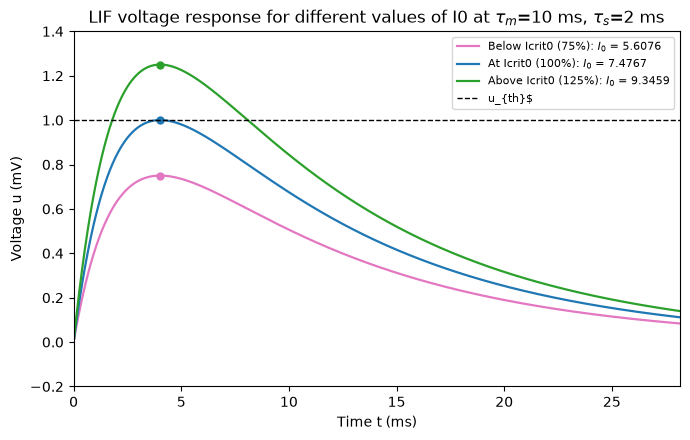

In [84]:
fig1, axis1 = plt.subplots(figsize=(7, 4.5), sharex=True)
colors = ["tab:pink", "tab:blue", "tab:green"]

for (label, I0, t_peak_vals, u_peak_vals, t_vals, u_vals), c in zip(plot_data, colors):
    axis1.plot(t_vals, u_vals, color = c, lw = 1.6, label = f"{label}: $I_0$ = {I0:.4f}")
    axis1.plot(t_peak_vals, u_peak_vals, "o", color = c, markersize = 5)

axis1.axhline(u_th, color = "k", ls ="--", lw = 1, label = r"u_{th}$") # Threshold line
axis1.set_xlabel("Time t (ms)")
axis1.set_ylabel("Voltage u (mV)")
axis1.set_title("LIF voltage response for different values of I0 at " + r"$\tau_m$=" f"{tau_m:g} ms, " + r"$\tau_s$=" + f"{tau_s:g} ms")
axis1.set_xlim(0, 7 * t_peak)
axis1.set_ylim(-0.2, 1.4)
axis1.legend(fontsize = 8)
fig1.tight_layout()
plt.show()

Plot: Icrit0 against tau_s over range of [0.5,100] ms on log-log axes

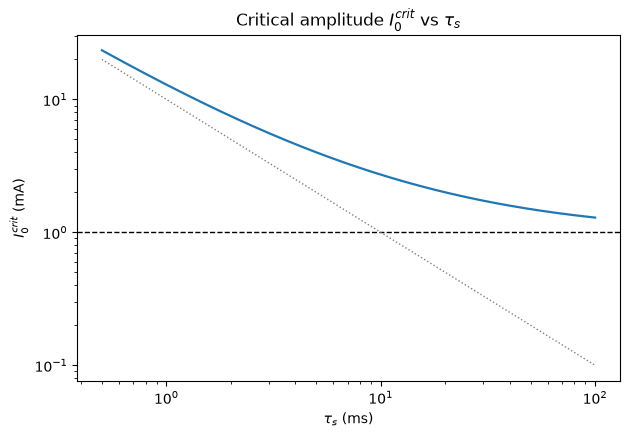

In [81]:
tau_s_sweep = np.logspace(np.log10(0.5), np.log10(100), 500)    #take 500 data points from range 0.5 to 100 ms
r_sweep = tau_s_sweep/tau_m
with np.errstate(divide = "ignore", invalid = "ignore"):
    Icrit_sweep = ((u_th - u_rest) / R * (tau_s_sweep / tau_m)**(tau_m/(tau_s_sweep - tau_m)))

near_tau_m = np.isclose(tau_s_sweep, tau_m, atol=1e-6)
Icrit_sweep[near_tau_m] = (u_th - u_rest) / R * np.e

fig2, axis2 = plt.subplots(figsize=(7, 4.5))
axis2.loglog(tau_s_sweep, Icrit_sweep, lw = 1.6, color = "tab:blue", label=r"$I_{0}^{crit}(\tau_s)$")
axis2.axhline((u_th - u_rest) / R, color = "k", ls ="--", lw = 1, label = r"Threshold") # Threshold line
asymptote = (u_th - u_rest) / R * (tau_m / tau_s_sweep)
axis2.loglog(tau_s_sweep, asymptote, ":", color="gray", lw = 1, label = r"Asymptote proportional to tau_s")     # where the constant current passes the threshold line
axis2.set_xlabel(r"$\tau_s$ (ms)") 
axis2.set_ylabel(r"$I_{0}^{crit}$ (mA)")
axis2.set_title(r"Critical amplitude $I_{0}^{crit}$ vs $\tau_s$")
fig1.tight_layout()
plt.show()

As Icrit0 nears tau_s at 0.5, the value of Icrit0 increases logarithmically. As Icrit0 approaches tau_s at 100, it's value progressivly approaches log10(0), getting smaller and smaller for infinity.